## 1. Setup and Data Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


In [ ]:
transactions = pd.read_excel('/content/drive/MyDrive/Data Analyst Thực Chiến/Lecture 2/Homework/QVI_transaction_data.xlsx')
customer_behavior = pd.read_csv('/content/drive/MyDrive/Data Analyst Thực Chiến/Lecture 2/Homework/QVI_purchase_behaviour.csv')


## 2. Data Exploration and Validation


In [ ]:
if 'DATE' in transactions.columns:
    if transactions['DATE'].dtype != 'datetime64[ns]':
        if pd.api.types.is_numeric_dtype(transactions['DATE']):
            # Assume Excel serial number (days since 1899-12-30)
            transactions['DATE'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(transactions['DATE'], unit='D')
        else:
            # Try parsing string dates
            transactions['DATE'] = pd.to_datetime(transactions['DATE'], errors='coerce')


## 3. RFM Metrics Calculation


### 3.1 Calculate Base RFM Values

In [ ]:
reference_date = transactions['DATE'].max() + timedelta(days=1)

rfm_data = transactions.groupby('LYLTY_CARD_NBR').agg({
    'DATE': lambda x: (reference_date - x.max()).days,  # Recency
    'TXN_ID': 'count',  # Frequency
    'TOT_SALES': 'sum'  # Monetary
}).reset_index()

In [ ]:
rfm_data.columns = ['LYLTY_CARD_NBR', 'Recency', 'Frequency', 'Monetary']
print(f"RFM metrics calculated for {len(rfm_data):,} customers")

RFM metrics calculated for 72,637 customers


### 3.2. RFM Value Distribution Analysis

*   Visualize distribution of R, F, and M values
*   Identify outliers and handle appropriately
*   Check for any calculation anomalies

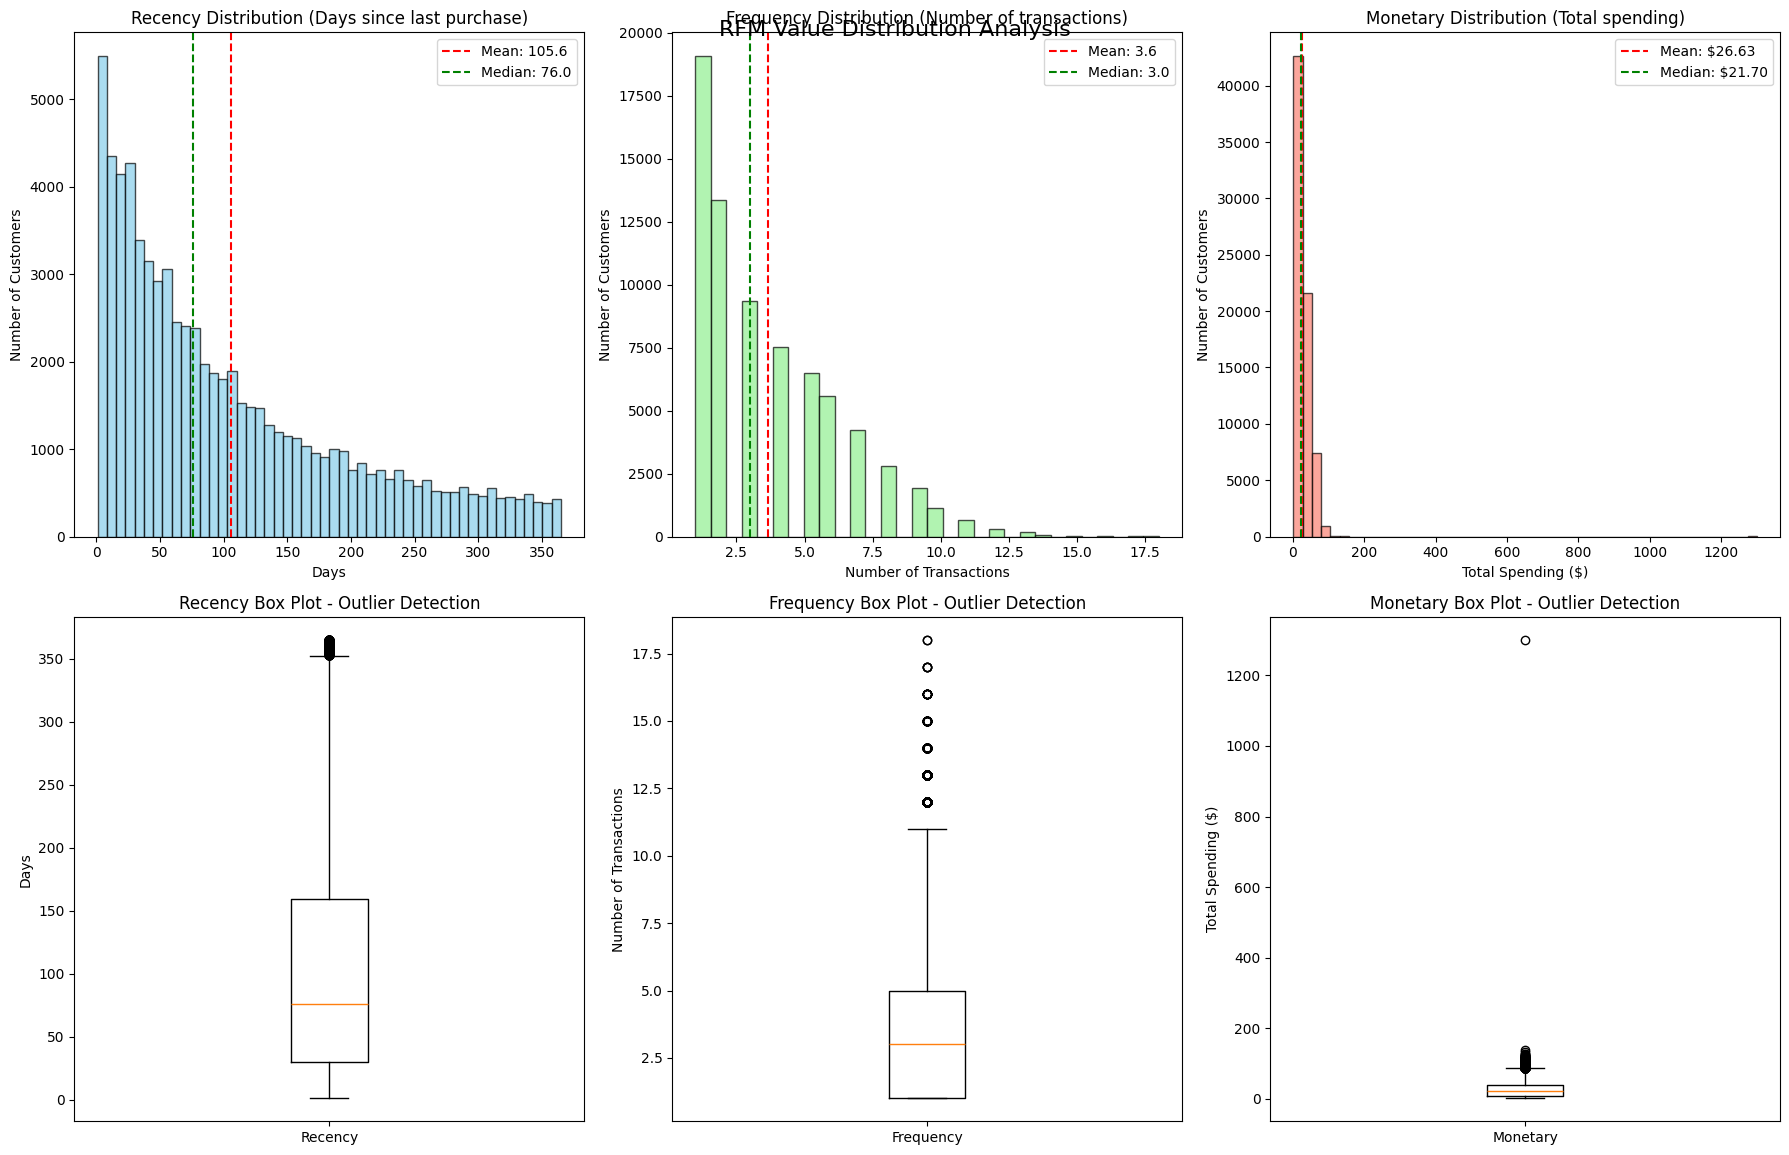

In [ ]:
# 2. VISUALIZE DISTRIBUTIONS
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('RFM Value Distribution Analysis', fontsize=16, y=0.95)

# Row 1: Histograms with KDE
# Recency
axes[0, 0].hist(rfm_data['Recency'], bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rfm_data['Recency'].mean(), color='red', linestyle='--', label=f'Mean: {rfm_data["Recency"].mean():.1f}')
axes[0, 0].axvline(rfm_data['Recency'].median(), color='green', linestyle='--', label=f'Median: {rfm_data["Recency"].median():.1f}')
axes[0, 0].set_title('Recency Distribution (Days since last purchase)')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].legend()

# Frequency
axes[0, 1].hist(rfm_data['Frequency'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rfm_data['Frequency'].mean(), color='red', linestyle='--', label=f'Mean: {rfm_data["Frequency"].mean():.1f}')
axes[0, 1].axvline(rfm_data['Frequency'].median(), color='green', linestyle='--', label=f'Median: {rfm_data["Frequency"].median():.1f}')
axes[0, 1].set_title('Frequency Distribution (Number of transactions)')
axes[0, 1].set_xlabel('Number of Transactions')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].legend()

# Monetary
axes[0, 2].hist(rfm_data['Monetary'], bins=50, color='salmon', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(rfm_data['Monetary'].mean(), color='red', linestyle='--', label=f'Mean: ${rfm_data["Monetary"].mean():.2f}')
axes[0, 2].axvline(rfm_data['Monetary'].median(), color='green', linestyle='--', label=f'Median: ${rfm_data["Monetary"].median():.2f}')
axes[0, 2].set_title('Monetary Distribution (Total spending)')
axes[0, 2].set_xlabel('Total Spending ($)')
axes[0, 2].set_ylabel('Number of Customers')
axes[0, 2].legend()

# Row 2: Box plots for outlier detection
axes[1, 0].boxplot(rfm_data['Recency'], vert=True)
axes[1, 0].set_title('Recency Box Plot - Outlier Detection')
axes[1, 0].set_ylabel('Days')
axes[1, 0].set_xticks([1])
axes[1, 0].set_xticklabels(['Recency'])

axes[1, 1].boxplot(rfm_data['Frequency'], vert=True)
axes[1, 1].set_title('Frequency Box Plot - Outlier Detection')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels(['Frequency'])

axes[1, 2].boxplot(rfm_data['Monetary'], vert=True)
axes[1, 2].set_title('Monetary Box Plot - Outlier Detection')
axes[1, 2].set_ylabel('Total Spending ($)')
axes[1, 2].set_xticks([1])
axes[1, 2].set_xticklabels(['Monetary'])

plt.tight_layout()
plt.show()


In [ ]:
# Remove outliers (Monetary) based on percentiles
percentile_99 = rfm_data['Monetary'].quantile(0.99)

rfm_data = rfm_data[rfm_data['Monetary'] <= percentile_99].copy()

In [ ]:
rfm_data

,LYLTY_CARD_NBR,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,1000,257,1,6.0,1,1,1,111,Lost
1,1002,288,1,2.7,1,1,1,111,Lost
2,1003,115,2,6.6,2,2,1,221,Lost
3,1004,241,1,1.9,1,1,1,111,Lost
4,1005,185,1,2.8,1,1,1,111,Lost
...,...,...,...,...,...,...,...,...,...
72632,2370651,332,1,13.0,1,2,2,122,Lost
72633,2370701,205,1,7.2,1,2,1,121,Lost
72634,2370751,273,1,9.2,1,2,2,122,Lost
72635,2370961,247,2,18.6,1,2,2,122,Lost


In [ ]:
rfm_data[rfm_data['Segment'] == 'Lost']

,LYLTY_CARD_NBR,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,1000,257,1,6.0,1,1,1,111,Lost
1,1002,288,1,2.7,1,1,1,111,Lost
2,1003,115,2,6.6,2,2,1,221,Lost
3,1004,241,1,1.9,1,1,1,111,Lost
4,1005,185,1,2.8,1,1,1,111,Lost
...,...,...,...,...,...,...,...,...,...
72632,2370651,332,1,13.0,1,2,2,122,Lost
72633,2370701,205,1,7.2,1,2,1,121,Lost
72634,2370751,273,1,9.2,1,2,2,122,Lost
72635,2370961,247,2,18.6,1,2,2,122,Lost


<Axes: >

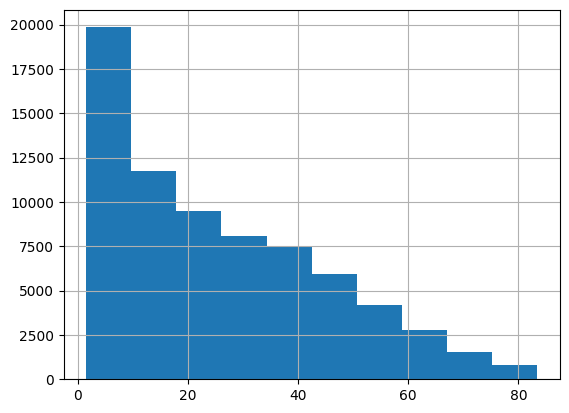

In [ ]:
rfm_data['Monetary'].hist()

## 4. RFM Scoring Implementation


### 4.1. Create Quartile-Based Scores
* Calculate quartiles for each RFM dimension
* Assign scores 1-4 (4 being best)
* Create R_score, F_score, M_score columns


In [ ]:
# Create quartile-based scores
rfm_data['R_score'] = pd.qcut(rfm_data['Recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop')
rfm_data['F_score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm_data['M_score'] = pd.qcut(rfm_data['Monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop')

# Convert to numeric
rfm_data['R_score'] = rfm_data['R_score'].astype(int)
rfm_data['F_score'] = rfm_data['F_score'].astype(int)
rfm_data['M_score'] = rfm_data['M_score'].astype(int)

### 4.2. Calculate Combined RFM Score
* Implement formula: RFM_Score = R × 100 + F × 10 + M
* Validate score ranges (111 to 444)
* Add RFM_score column to dataset


In [ ]:
rfm_data['RFM_Score'] = rfm_data['R_score'] * 100 + rfm_data['F_score'] * 10 + rfm_data['M_score']


## 5. Customer Segmentation


In [ ]:
def segment_customers(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['F_score'] <= 2 and row['M_score'] <= 2:
        return 'New Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2 and row['M_score'] >= 3:
        return 'Can\'t Lose Them'
    elif row['R_score'] >= 3 and row['M_score'] <= 2:
        return 'Promising'
    elif row['R_score'] <= 2 and row['F_score'] <= 2 and row['M_score'] <= 2:
        return 'Lost'
    else:
        return 'Need Attention'

rfm_data['Segment'] = rfm_data.apply(segment_customers, axis=1)

## 6. Segment Performance Analysis

### 6.1 Segment Size and Value


In [ ]:
segment_summary = rfm_data.groupby('Segment').agg({
    'LYLTY_CARD_NBR': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['sum', 'mean']
}).round(2)

segment_summary.columns = ['Customers', 'Avg_Recency', 'Avg_Frequency', 'Total_Revenue', 'Avg_Revenue']
segment_summary['Customer_%'] = (segment_summary['Customers'] / segment_summary['Customers'].sum() * 100).round(1)
segment_summary['Revenue_%'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(1)

print("\nSEGMENT SUMMARY:")
print(segment_summary.sort_values('Total_Revenue', ascending=False))



SEGMENT SUMMARY:
                 Customers  Avg_Recency  Avg_Frequency  Total_Revenue  \
Segment                                                                 
Loyal Customers      16299        39.37           5.38      654344.05   
Champions             7387        14.66           7.64      416078.30   
At Risk               9454       129.35           4.94      360382.30   
Lost                 23580       203.33           1.39      214665.45   
New Customers         9607        38.14           1.65      102466.50   
Need Attention        2631        90.74           3.01       55805.95   
Can't Lose Them       1427       158.36           2.77       36320.25   
Promising             1529        35.29           3.30       25798.05   

                 Avg_Revenue  Customer_%  Revenue_%  
Segment                                              
Loyal Customers        40.15        22.7       35.1  
Champions              56.33        10.3       22.3  
At Risk                38.12       

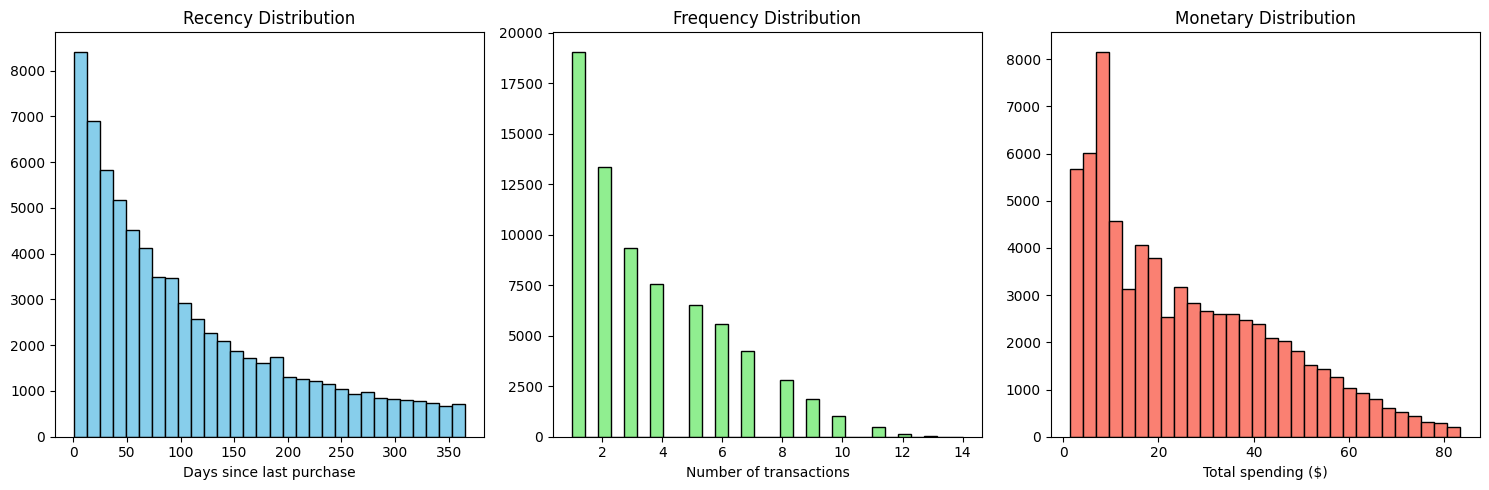

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].hist(rfm_data['Recency'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')

axes[1].hist(rfm_data['Frequency'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of transactions')

axes[2].hist(rfm_data['Monetary'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spending ($)')

plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!pip install squarify

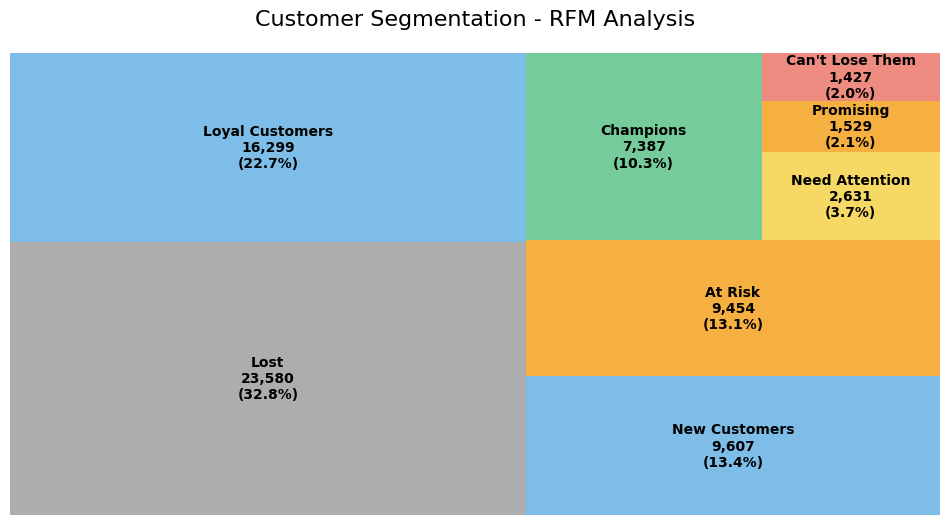

In [ ]:
segment_counts = rfm_data['Segment'].value_counts().to_dict()

# Calculate percentages
total = sum(segment_data.values())
labels = [f'{k}\n{v:,}\n({v/total*100:.1f}%)' for k, v in segment_data.items()]

# Define colors
colors = ['#999999', '#5DADE2', '#5DADE2', '#F39C12',
          '#52BE80', '#F4D03F', '#F39C12', '#EC7063']

# Create treemap
plt.figure(figsize=(12, 6))
squarify.plot(sizes=list(segment_data.values()),
              label=labels,
              color=colors,
              alpha=0.8,
              text_kwargs={'fontsize': 10, 'weight': 'bold'})

plt.axis('off')
plt.title('Customer Segmentation - RFM Analysis', fontsize=16, pad=20)
plt.show()

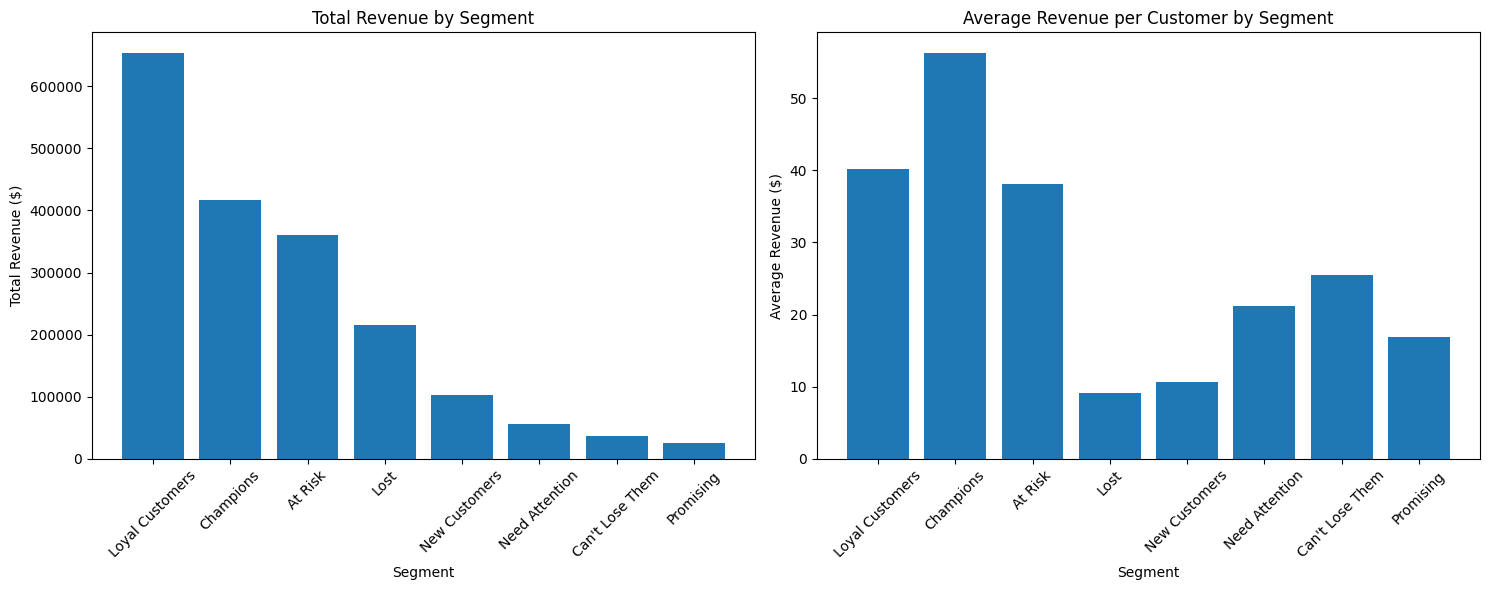

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Revenue by segment
segment_revenue = segment_summary.sort_values('Total_Revenue', ascending=False)
ax1.bar(segment_revenue.index, segment_revenue['Total_Revenue'])
ax1.set_title('Total Revenue by Segment')
ax1.set_xlabel('Segment')
ax1.set_ylabel('Total Revenue ($)')
ax1.tick_params(axis='x', rotation=45)

# Average revenue per customer
ax2.bar(segment_revenue.index, segment_revenue['Avg_Revenue'])
ax2.set_title('Average Revenue per Customer by Segment')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Average Revenue ($)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('segment_value_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
segment_summary

,Customer_Count,Total_Revenue,% Customer Base,% Revenue
Segment,,,,
Loyal Customers,16299,654344.05,22.664572,35.069285
Champions,7387,416078.30,10.271992,22.299535
At Risk,9454,360382.30,13.146258,19.314532
Lost,23580,214665.45,32.789165,11.504901
New Customers,9607,102466.50,13.359012,5.491647
Need Attention,2631,55805.95,3.658537,2.990896
Can't Lose Them,1427,36320.25,1.984315,1.946568
Promising,1529,25798.05,2.126151,1.382635


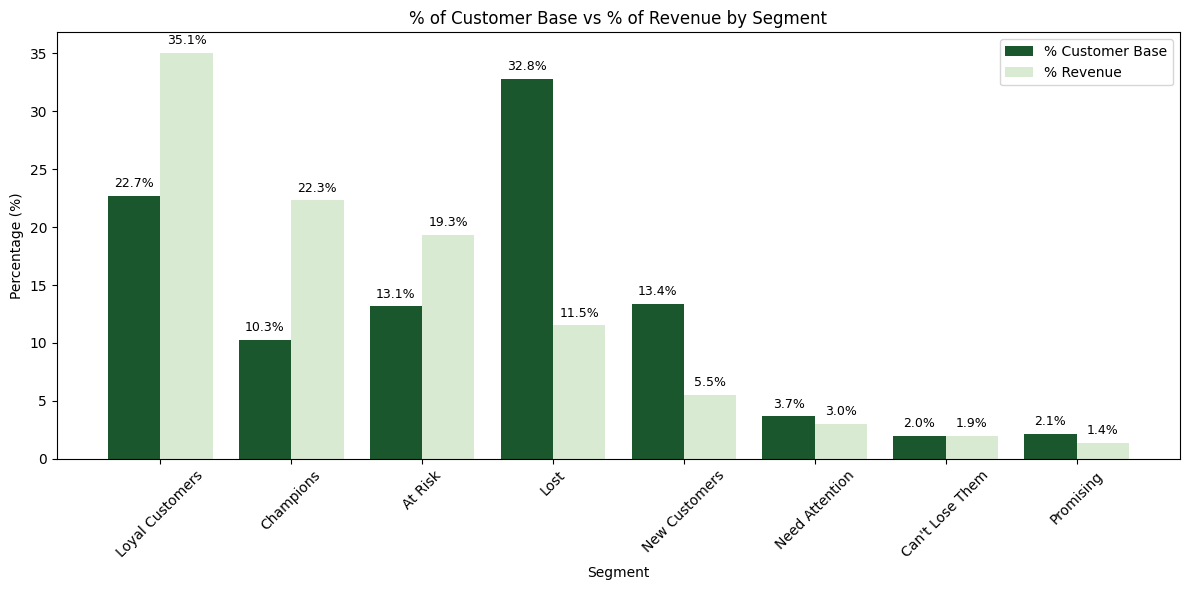

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(segment_summary))
width = 0.4

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], segment_summary['% Customer Base'], width=width, label='% Customer Base', color = "#1a572cff")
bars2 = ax.bar([i + width/2 for i in x], segment_summary['% Revenue'], width=width, label='% Revenue', color = "#d9ead3ff")

# Add value labels on bars
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Labels and formatting
ax.set_title('% of Customer Base vs % of Revenue by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(segment_summary.index, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()


### 6.2 Segment Demographics Integration
* Merge RFM segments with customer demographics
* Analyze LIFESTAGE distribution within each segment
* Analyze PREMIUM_CUSTOMER distribution within each segment
* Create cross-tabulation tables
* Identify demographic patterns (e.g., Champions are mostly Premium customers)


In [ ]:
print("\n8. Demographic Analysis...")
rfm_demographics = rfm_data.merge(customer_behavior, on='LYLTY_CARD_NBR', how='left')

# Premium customer analysis
premium_analysis = pd.crosstab(rfm_demographics['Segment'],
                              rfm_demographics['PREMIUM_CUSTOMER'],
                              normalize='index') * 100

print("\nPREMIUM CUSTOMER DISTRIBUTION BY SEGMENT (%):")
print(premium_analysis.round(1))

# Lifestage analysis
lifestage_analysis = pd.crosstab(rfm_demographics['Segment'],
                                rfm_demographics['LIFESTAGE'],
                                normalize='index') * 100

print("\nTOP LIFESTAGE BY SEGMENT:")
for segment in lifestage_analysis.index:
    top_lifestage = lifestage_analysis.loc[segment].idxmax()
    percentage = lifestage_analysis.loc[segment, top_lifestage]
    print(f"{segment}: {top_lifestage} ({percentage:.1f}%)")



8. Demographic Analysis...

PREMIUM CUSTOMER DISTRIBUTION BY SEGMENT (%):
PREMIUM_CUSTOMER  Budget  Mainstream  Premium
Segment                                      
At Risk             33.4        39.9     26.7
Can't Lose Them     30.1        45.1     24.7
Champions           37.5        36.5     26.0
Lost                32.8        41.9     25.3
Loyal Customers     34.1        38.9     27.0
Need Attention      30.8        43.6     25.6
New Customers       33.0        40.9     26.1
Promising           34.5        39.4     26.0

TOP LIFESTAGE BY SEGMENT:
At Risk: OLDER SINGLES/COUPLES (25.4%)
Can't Lose Them: YOUNG SINGLES/COUPLES (26.2%)
Champions: OLDER FAMILIES (27.1%)
Lost: YOUNG SINGLES/COUPLES (28.3%)
Loyal Customers: OLDER SINGLES/COUPLES (25.0%)
Need Attention: YOUNG SINGLES/COUPLES (27.6%)
New Customers: YOUNG SINGLES/COUPLES (27.7%)
Promising: YOUNG SINGLES/COUPLES (25.7%)


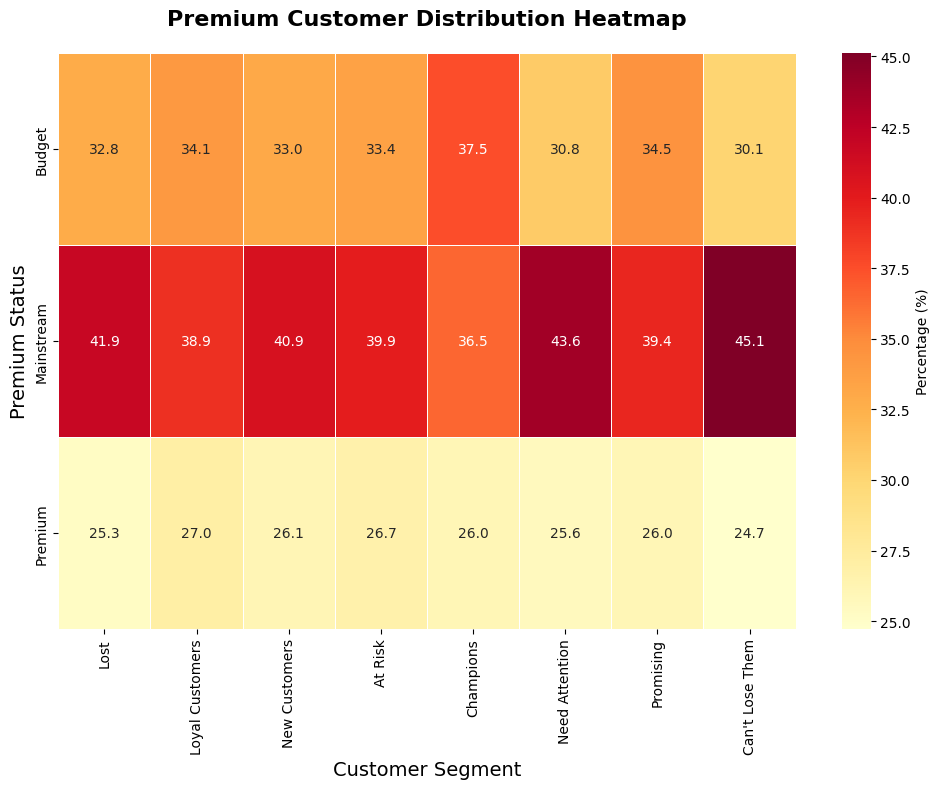

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(premium_analysis_sorted.T,
            annot=True,
            fmt='.1f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Percentage (%)'},
            linewidths=0.5)

plt.title('Premium Customer Distribution Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Premium Status', fontsize=14)
plt.tight_layout()
plt.show()


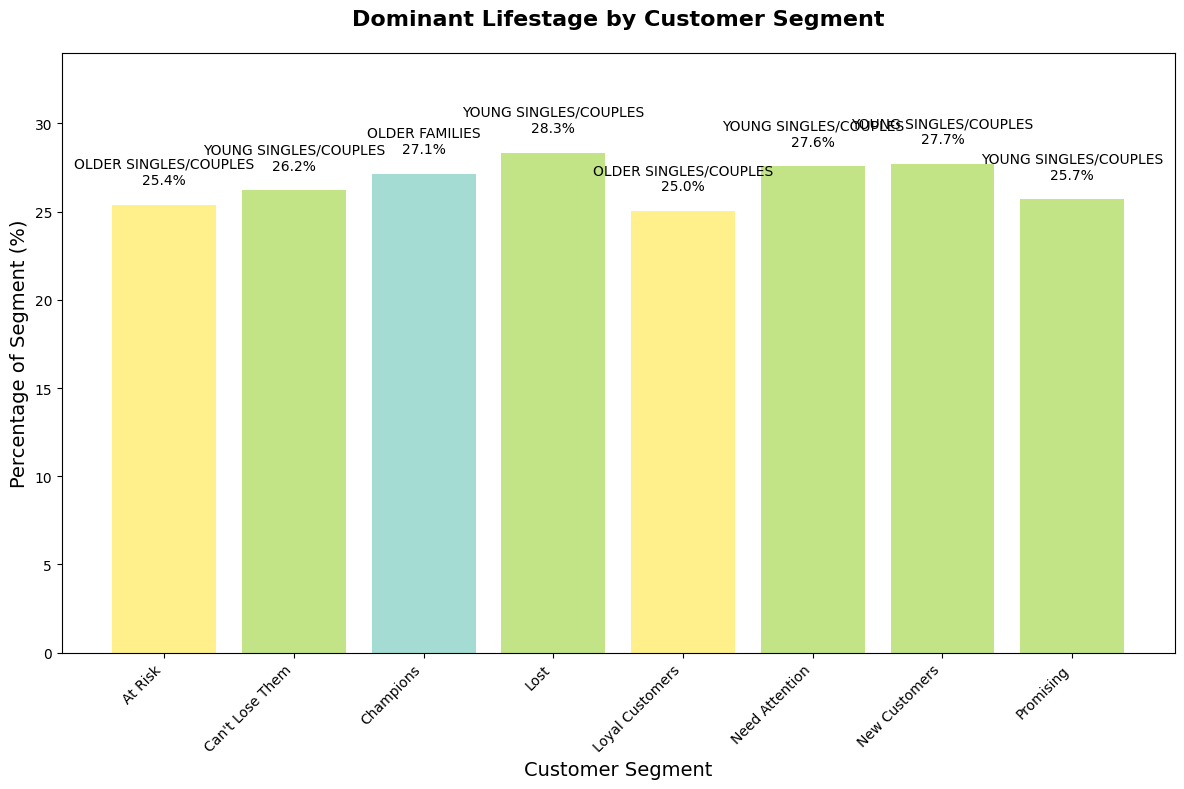

In [ ]:
lifestage_analysis = pd.crosstab(rfm_demographics['Segment'],
                                rfm_demographics['LIFESTAGE'],
                                normalize='index') * 100

# Get top lifestage for each segment
top_lifestages = {}
for segment in lifestage_analysis.index:
    top_lifestage = lifestage_analysis.loc[segment].idxmax()
    percentage = lifestage_analysis.loc[segment, top_lifestage]
    top_lifestages[segment] = {'lifestage': top_lifestage, 'percentage': percentage}

# Create bar chart of dominant lifestages
plt.figure(figsize=(12, 8))
segments = list(top_lifestages.keys())
percentages = [top_lifestages[seg]['percentage'] for seg in segments]
lifestages = [top_lifestages[seg]['lifestage'] for seg in segments]

# Color by lifestage
unique_lifestages = list(set(lifestages))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_lifestages)))
color_map = dict(zip(unique_lifestages, colors))
bar_colors = [color_map[ls] for ls in lifestages]

bars = plt.bar(segments, percentages, color=bar_colors, alpha=0.8)

# Add labels
for i, (seg, pct, ls) in enumerate(zip(segments, percentages, lifestages)):
    plt.text(i, pct + 1, f'{ls}\n{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Dominant Lifestage by Customer Segment', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Percentage of Segment (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(percentages) * 1.2)
plt.tight_layout()
plt.show()

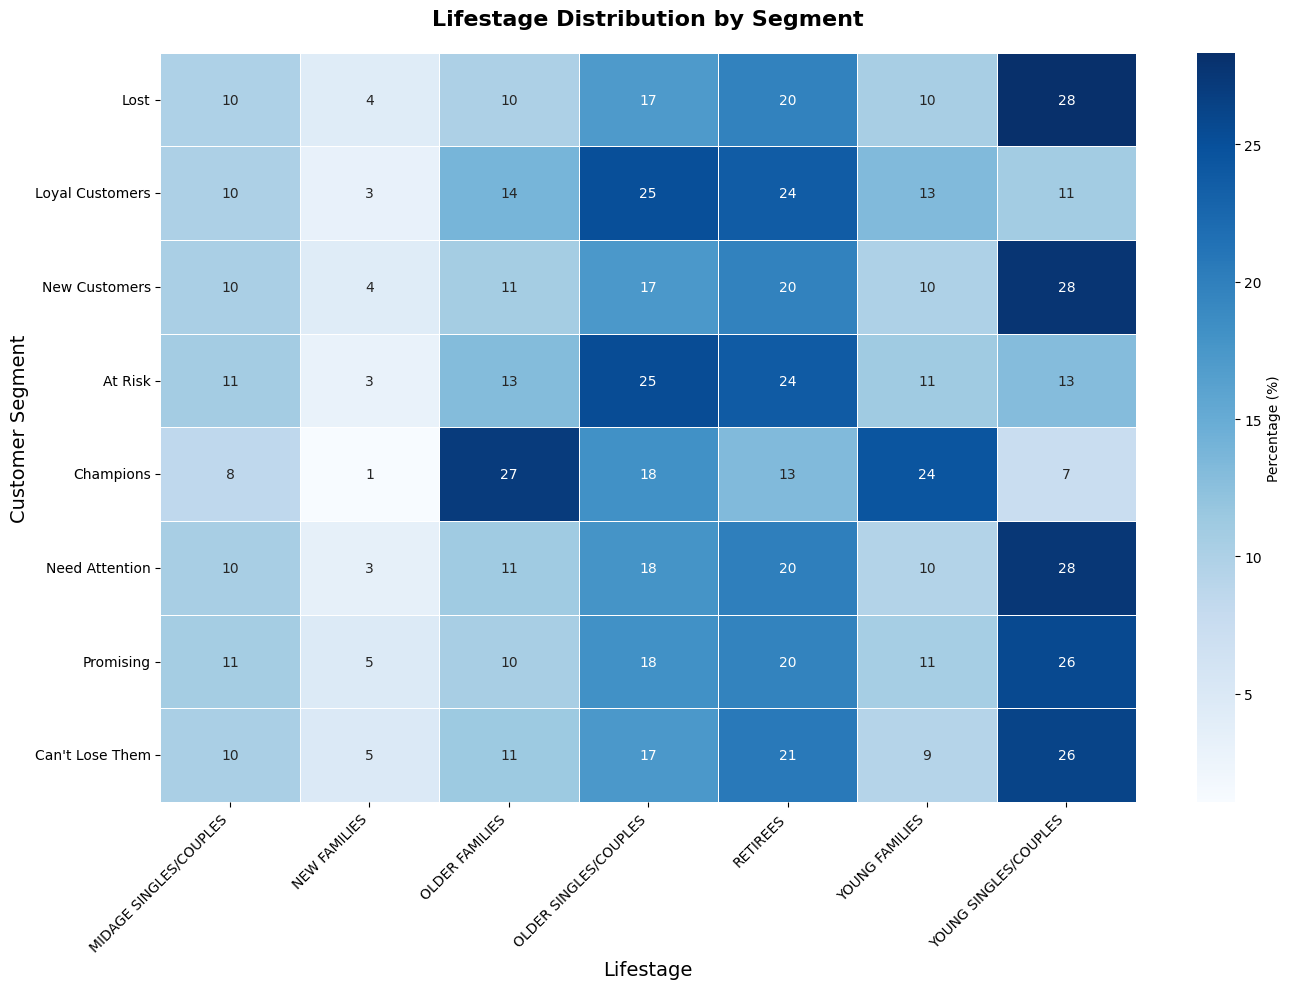

In [ ]:
plt.figure(figsize=(14, 10))

# Sort segments by total customers
lifestage_analysis_sorted = lifestage_analysis.reindex(segment_order)

# Create heatmap
sns.heatmap(lifestage_analysis_sorted,
            annot=True,
            fmt='.0f',
            cmap='Blues',
            cbar_kws={'label': 'Percentage (%)'},
            linewidths=0.5)

plt.title('Lifestage Distribution by Segment', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Lifestage', fontsize=14)
plt.ylabel('Customer Segment', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()